In [1]:
import numpy as np
import matplotlib.pyplot as plt
# import seaborn as sns
from tda_methods import LSTMAutoencoder, GeometryConverter, PersistencePlotter, TakensEmbedding, WassersteinDistance, \
      plot_3d_points, numpy_to_torch, window_2d_sequence_to_3d, write_results_to_file, plot_all_features_in_2d_array, plot_latent_evolution_grid
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch


In [ ]:
"Torus/Sphere data"

rng     = np.random.default_rng()
start_point, end_point, n_points = 0, 2*np.pi, 1000
u_angle = rng.uniform(start_point, end_point, n_points)
v_angle = rng.uniform(start_point, end_point, n_points)

# u, v = np.meshgrid(u, v)

R_major   = 1
r_tube    = R_major/4
converter = GeometryConverter(R_major, r_tube)
x, y, z   = converter.convert_angles_to_torus_xyz(u_angle, v_angle)
# # x, y, z   = converter.convert_angles_to_sphere_xyz(u_angle, v_angle)
noise = rng.normal(0, 0.04, n_points)
x += noise  # Add some noise to v
y += noise  # Add some noise to u
z += noise  # Add some noise to both
geo_coordinates = np.column_stack((x, y, z))  # shape (N, 3)

# x1,y1,z1,x2,y2,z2 = converter.convert_angles_to_2torus_xyz(u_angle, v_angle, d_shift=R_major)
# geo_coordinates   = np.vstack([np.column_stack((x1,y1,z1)), np.column_stack((x2,y2,z2))])
plot_3d_points((geo_coordinates[:, 0], geo_coordinates[:, 1], geo_coordinates[:, 2]))


In [ ]:
"persistence"

persistence    = PersistencePlotter(max_dim=1)
diagrams_list  = persistence.compute_persistence_diagrams(geo_coordinates)
diagrams_clean = persistence.remove_inf(diagrams_list)
entropy_array  = persistence.compute_entropy(diagrams_clean)
persistence_images_list = persistence.compute_persistence_image(diagrams_clean)
betti_curves_array      = persistence.compute_betti_curves(diagrams_clean)

print("Persistence array:", entropy_array)
print("Betti curves shape: (batch, homology_dim, filtration_steps) =", betti_curves_array.shape)

persistence.plot_persistence_diagrams(diagrams_list)
persistence.plot_entropy(entropy_array)
persistence.plot_persistence_image(persistence_images_list[1])  # H1
persistence.plot_betti_curves(betti_curves_array)


In [ ]:
"timedelay embeddings"

x  = np.linspace(0, 14*np.pi, 1000)
y1 = (0.5+0.5*x) * np.sin(2*x + 1) + 0.04 * rng.normal(size=x.shape)
y2 = 1.5*np.sin(2 * x) #+ 0.05 * (x-2)**1.2 #+ 0.02 * rng.normal(size=x.shape)
plt.figure()
plt.plot(x, y1, label='y1')
plt.plot(x, y2, label='y2')
plt.legend()
plt.show()

min_len = min(len(y1), len(y2))
y1, y2  = y1[:min_len], y2[:min_len]

time_delay, lag_dim = 20, 4
y1_delay_embeddings = make_timedelay_embeddings(y1, time_delay, lag_dim)
y1_now, y1_delayed  = y1_delay_embeddings[:, 0], y1_delay_embeddings[:, 1]

# time_delay2, lag_dim2 = 20, 4
y2_delay_embeddings = make_timedelay_embeddings(y2, time_delay, lag_dim)
y2_now, y2_delayed  = y2_delay_embeddings[:, 0], y2_delay_embeddings[:, 1]
plt.figure()
# plt.scatter(y1_now, y1_delayed, s=4)
plt.scatter(y2_now, y2_delayed, s=4)
plt.show()

# persistence stuff
persistence  = PersistencePlotter(max_dim=1)
n            = min(len(y1_delay_embeddings), len(y2_delay_embeddings))
y_all        = np.hstack((y1_delay_embeddings[:n], y2_delay_embeddings[:n]))
# y_data       = np.column_stack((y1_now, y1_delayed))
diagrams_list = persistence.compute_persistence_diagrams(y_all)
persistence.plot_persistence_diagrams(diagrams_list, title="y_all")


X shape (15000, 3)
X_windows shape: (1139, 200, 3)
X_train/test shape: (911, 200, 3) (228, 200, 3)


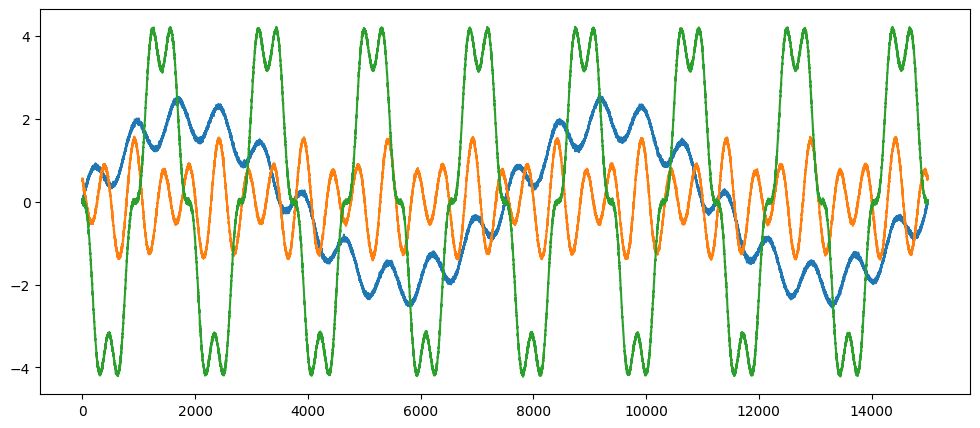

In [2]:
"⚽️ Setting up data"
rng     = np.random.default_rng()

num_timesteps = 15_000
timesteps     = np.linspace(0, 20*np.pi, num_timesteps)
# X1 = np.sin(timesteps) * ((0.5+0.5*timesteps) * np.sin(2*timesteps + 1)) + 0.03 * rng.normal(size=timesteps.shape)
X1 = (2.0 * np.sin(0.2 * timesteps)) + 0.5 * np.sin(2*timesteps) + 0.03 * rng.normal(size=timesteps.shape)
X2 = np.cos(3*timesteps + 1) + 0.5 * np.sin(2*timesteps) + 0.03 * rng.normal(size=timesteps.shape)
X3 = -(4.0 * np.sin(0.8 * timesteps)) + 0.8 * np.sin(4*timesteps) + 0.03 * rng.normal(size=timesteps.shape)
X  = np.column_stack((X1, X2, X3))

window_size     = 200
stride          = window_size//15
X_windows       = window_2d_sequence_to_3d(X, window_size, stride)
X_train_3d, X_test_3d = train_test_split(X_windows, test_size=0.2, random_state=42, shuffle=False)

# scaling works for 2d, so reshape to 2d, scale, and reshape back
scaler         = StandardScaler()
X_train_2d     = X_train_3d.reshape(-1, X_train_3d.shape[-1])
X_test_2d      = X_test_3d.reshape(-1, X_test_3d.shape[-1])
X_train = scaler.fit_transform(X_train_2d).reshape(X_train_3d.shape)
X_test  = scaler.transform(X_test_2d).reshape(X_test_3d.shape)

# takens_object   = TakensEmbedding(delay=8, embedding_dim=3)
# X_train_takens  = takens_object.make_timedelay_embeddings_grid(X_train)
# X_test_takens   = takens_object.make_timedelay_embeddings_grid(X_test)

print("X shape", X.shape)
print("X_windows shape:", X_windows.shape)
print("X_train/test shape:", X_train.shape, X_test.shape)

plt.figure(figsize=(12, 5))
plt.plot(X1, label='Original Data')
plt.plot(X2, label='Original Data')
plt.plot(X3, label='Original Data')


Epoch 20/100, Loss: 0.0041
Epoch 40/100, Loss: 0.0027
Early stopping at epoch 53, loss = 0.0027


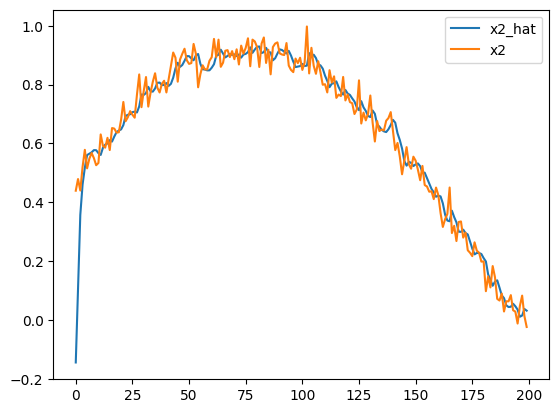

In [3]:
"train + eval LSTM encoder"

X_train, X_test    = numpy_to_torch(X_train), numpy_to_torch(X_test)
input_dim          = X_train.shape[-1]
latent_dim         = 8
encoder_hidden_dim = 56
decoder_hidden_dim = 56
lstm_ae            = LSTMAutoencoder(input_dim, latent_dim, encoder_hidden_dim=encoder_hidden_dim,
                             decoder_hidden_dim=decoder_hidden_dim, epochs=100, learning_rate=0.001)
losses             = lstm_ae.train_model(X_train, patience=12)
device             = lstm_ae.device

# inference:
lstm_ae.eval()
with torch.no_grad():
    x_train_hat, z_train = lstm_ae(X_train.to(device))
    x_test_hat, z_test   = lstm_ae(X_test.to(device))

# visual test that encoder works on x_test
window_number, feature_number = 2, 1
plt.plot(x_test_hat[window_number, :, feature_number].cpu(), label=f'x{window_number}_hat')
plt.plot(X_test[window_number, :, feature_number].cpu(), label=f'x{window_number}')
plt.legend()
plt.show()


z_train=torch.Size([911, 8]), z_windowed= torch.Size([73, 113, 8]), z_win_takens= (73, 93, 24)


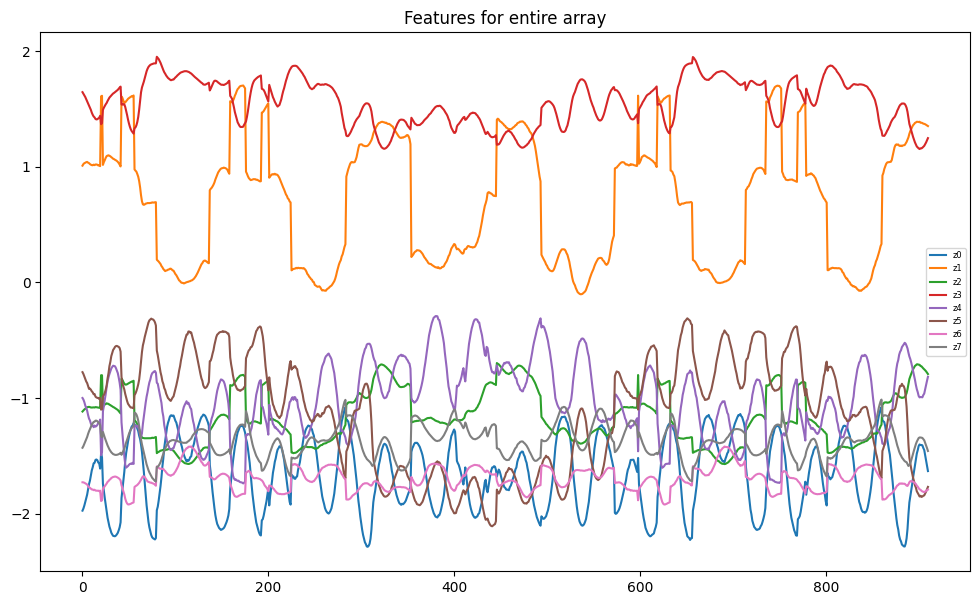

/home/fouadabiad/projects/timeseries_geo_ml/geo/topological_analysis/tda_methods.py:702: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(right=0.88) # right-side colorbar


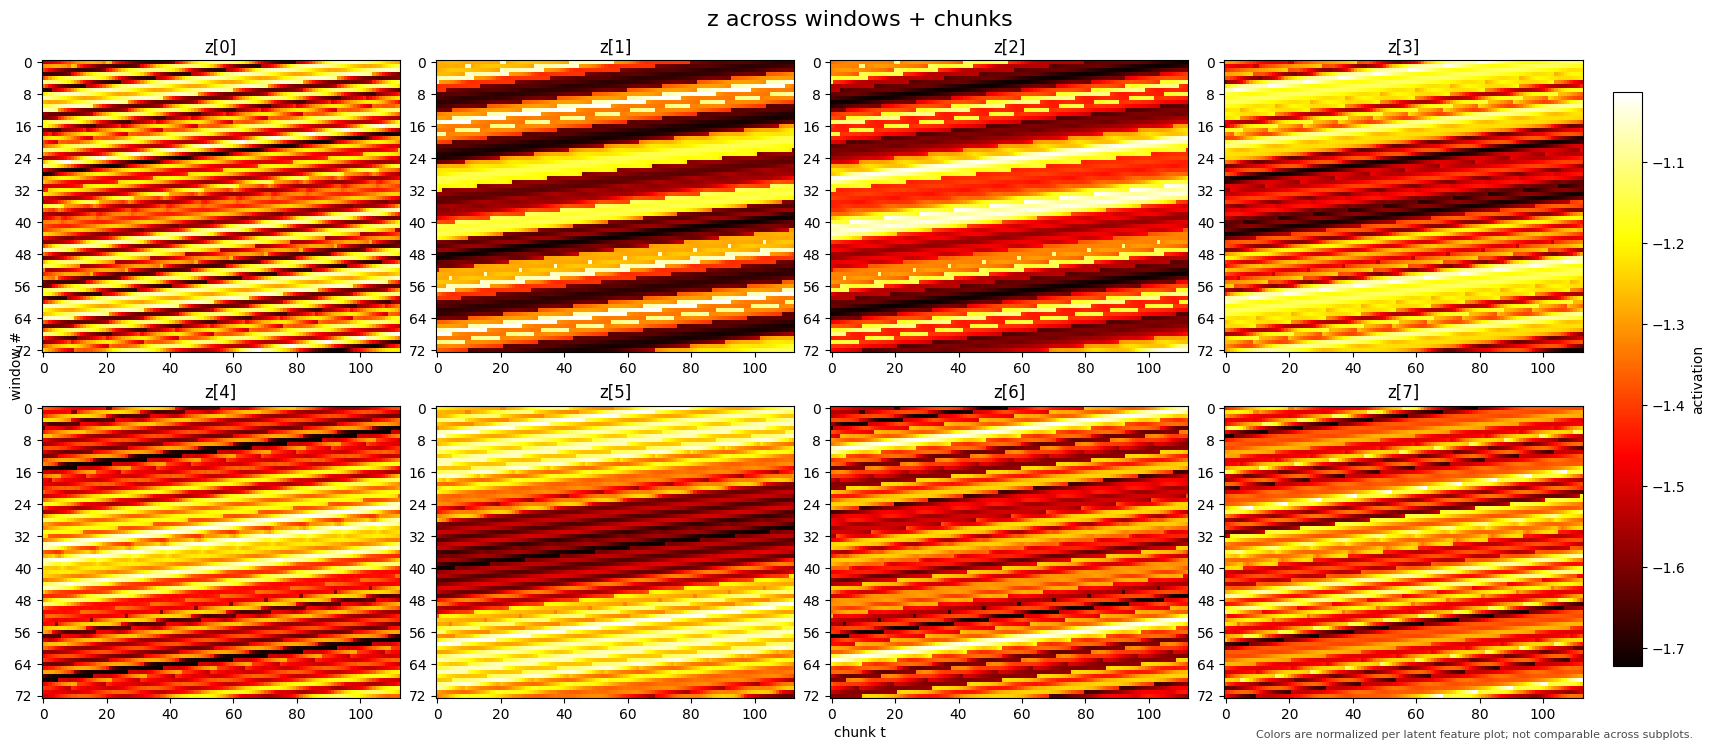

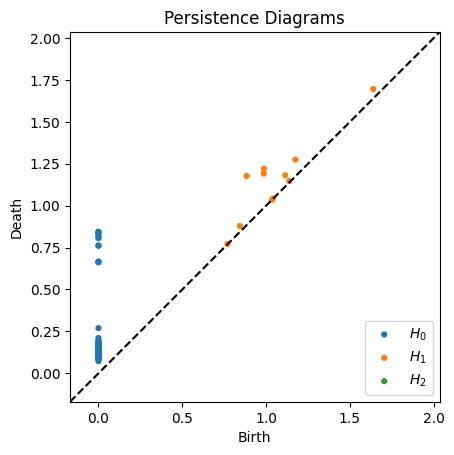

In [4]:
"plotting latents z"

window_fracion     = 8
window_stride_frac = window_fracion*10
# z_window_size   = z_train.shape[0]//8
# z_stride        = z_window_size//16
z_train_windows    = window_2d_sequence_to_3d(z_train, z_train.shape[0]//window_fracion, z_train.shape[0]//window_stride_frac)
z_test_windows     = window_2d_sequence_to_3d(z_test, z_test.shape[0]//window_fracion, z_test.shape[0]//window_stride_frac)

takens_obj     = TakensEmbedding(delay=10, embedding_dim=3)
z_train_takens = takens_obj.make_timedelay_embeddings_grid(z_train_windows)
z_test_takens  = takens_obj.make_timedelay_embeddings_grid(z_test_windows)
plotter        = PersistencePlotter(max_dim=2, pixel_size=0.2)
dgms           = plotter.remove_inf(plotter.compute_persistence_diagrams(z_train_takens[0]))

print(f"z_train={z_train.shape}, z_windowed= {z_train_windows.shape}, z_win_takens= {z_train_takens.shape}")

plot_all_features_in_2d_array(z_train, window_number=1)
plot_latent_evolution_grid(z_train_windows, max_latent_dims=8, n_plots_per_row=4)
plotter.plot_persistence_diagrams(dgms)

# A(t) = mean_k corr(z[:,k], z[:,k+τ])


In [ ]:
window = 2
plot_3d_points((z_train_takens[window][:, 0], z_train_takens[window][:, 1], z_train_takens[window][:, 2]), figsize=(6, 9))
plot_3d_points((z_train_windows[window][:, 0], z_train_windows[window][:, 1], z_train_windows[window][:, 2]), figsize=(6, 9))

/home/fouadabiad/projects/timeseries_geo_ml/.venv/lib/python3.11/site-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/home/fouadabiad/projects/timeseries_geo_ml/.venv/lib/python3.11/site-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/home/fouadabiad/projects/timeseries_geo_ml/.venv/lib/python3.11/site-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/home/fouadabiad/projects/timeseries_geo_ml/.venv/lib/python3.11/site-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
/home/fouadabiad/projects/timeseries_geo_ml/.venv/lib/python3.11/site-packages/ripser/ripser.py:257: UserWarning: The input point cloud has more columns than rows; did 

[1.19e+00 9.17e-01 1.27e-01 5.80e-01 5.67e-01 1.00e+00 5.80e-01 3.30e-01
 1.07e+00 1.07e+00 1.53e-01 1.07e-01 6.00e-01 3.80e-01 1.07e+00 1.76e+00
 4.03e-01 3.13e-01 9.33e-01 4.50e-01 9.10e-01 3.08e+00 4.67e-01 8.13e-01
 5.17e-01 7.10e-01 6.03e-01 1.90e-01 4.00e-02 2.83e-01 5.40e-01 2.40e-01
 1.59e+00 2.23e-01 4.50e-01 2.90e-01 3.53e-01 1.37e-01 6.57e-01 9.27e-01
 7.63e-01 1.17e+00 3.03e-01 3.40e-01 1.40e-01 5.37e-01 9.23e-01 7.83e-01
 4.97e-01 7.23e-01 5.23e-01 1.90e-01 6.57e-01 3.97e-01 5.53e-01 4.17e-01
 3.33e-01 4.37e-01 1.16e+00 4.33e-01 8.53e-01 8.97e-01 8.17e-01 2.77e-01
 9.33e-02 4.03e-01 8.13e-01 6.47e-01 1.72e+00 6.27e-01 5.10e-01 6.87e-01]
[3.09e-03 7.41e-03 9.85e-04 3.75e-03 1.33e-03 5.39e-04 3.50e-03 1.77e-03
 6.90e-03 5.86e-03 4.69e-04 1.69e-04 1.01e-03 2.41e-03 5.32e-03 5.09e-03
 1.85e-03 1.89e-03 2.58e-03 8.85e-04 1.60e-03 2.12e-03 2.05e-03 6.20e-04
 4.00e-03 3.07e-03 1.61e-03 7.76e-05 3.11e-04 1.83e-03 4.79e-04 8.92e-04
 1.52e-03 1.21e-03 1.22e-03 9.64e-04 2.09e-03 4.63

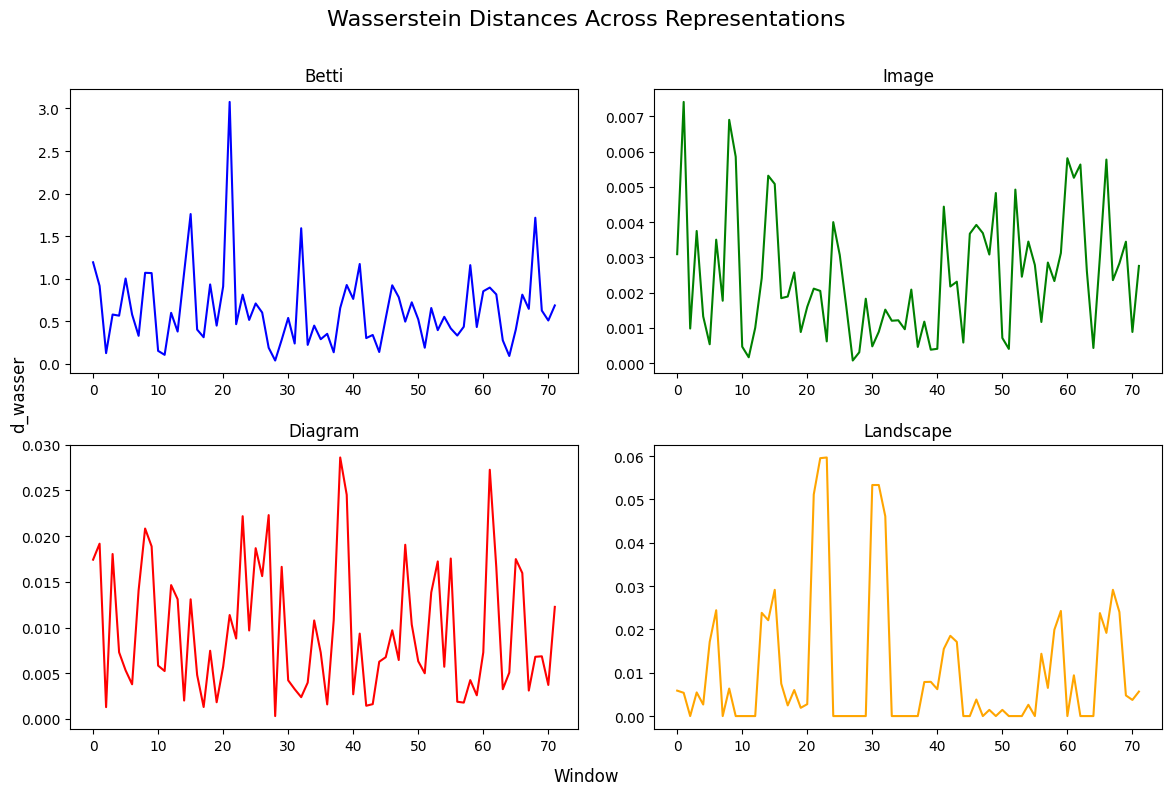

In [5]:
"d_wasserstein + plotting"
z_betti_train    = plotter.compute_persistence_features(z_train_takens, mode="betti")
z_image_train    = plotter.compute_persistence_features(z_train_takens, mode="image")
z_diagram_train  = plotter.compute_persistence_features(z_train_takens, mode="diagram")
z_landscape_train= plotter.compute_persistence_features(z_train_takens, mode="landscape")

z_betti_test    = plotter.compute_persistence_features(z_test_takens, mode="betti")
z_image_test    = plotter.compute_persistence_features(z_test_takens, mode="image")
z_diagram_test  = plotter.compute_persistence_features(z_test_takens, mode="diagram")
z_landscape_test= plotter.compute_persistence_features(z_test_takens, mode="landscape")

# print("betti features shape:", z_betti_train.shape)
# plotter.plot_persistence_grid(z_train_windows)
# plotter.plot_persistence_image_grid(z_train_windows)
# plotter.plot_betti_grid(z_train_windows)
# plotter.plot_landscape_grid(z_train_windows, num_steps=128, K_layers=3)

d_wasser_obj         = WassersteinDistance
betti_dist_train     = d_wasser_obj.compute_wasserstein_distance(z_betti_train, delay=1)
image_dist_train     = d_wasser_obj.compute_wasserstein_distance(z_image_train, delay=1)
diagram_dist_train   = d_wasser_obj.compute_wasserstein_distance(z_diagram_train, delay=1)
landscape_dist_train = d_wasser_obj.compute_wasserstein_distance(z_landscape_train, delay=1)

betti_dist_test     = d_wasser_obj.compute_wasserstein_distance(z_betti_test, delay=1)
image_dist_test     = d_wasser_obj.compute_wasserstein_distance(z_image_test, delay=1)
diagram_dist_test   = d_wasser_obj.compute_wasserstein_distance(z_diagram_test, delay=1)
landscape_dist_test = d_wasser_obj.compute_wasserstein_distance(z_landscape_test, delay=1)


print(np.array2string(betti_dist_train, formatter={'float_kind': lambda x: f"{x:.2e}"}))
print(np.array2string(image_dist_train, formatter={'float_kind': lambda x: f"{x:.2e}"}))
print(np.array2string(diagram_dist_train, formatter={'float_kind': lambda x: f"{x:.2e}"}))
print(np.array2string(landscape_dist_train, formatter={'float_kind': lambda x: f"{x:.2e}"}))

d_wasser_obj.plot_all_wasserstein_distances(betti_dist_train, image_dist_train, diagram_dist_train, landscape_dist_train)


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torchmetrics.regression import R2Score

# CONFIG
USE_EXOGENOUS = 0
EXOG_FEATURES = ["betti"]
N_RUNS = 8
EPOCHS = 50
H = 2 # prediction horizon

print(f"Using exogenous: {USE_EXOGENOUS} | Features: {EXOG_FEATURES} | Runs: {N_RUNS}")

exog_map = {
    "betti": {"train": betti_dist_train, "test": betti_dist_test},
    "image": {"train": image_dist_train, "test": image_dist_test},
    "diagram": {"train": diagram_dist_train, "test": diagram_dist_test},
    "landscape": {"train": landscape_dist_train, "test": landscape_dist_test}}

# DATA PREP
# -----------------------
def build_sequences(z: torch.Tensor, H: int):# -> tuple[torch.Tensor, torch.Tensor]:
    """Create (x, y) sequences from z. y = next H steps of last latent dim, x = all latent dims except last, aligned with y."""
    idx = torch.arange(len(z)-H)
    x   = z[:-H]
    y   = torch.stack([z[i+1:i+H+1, -1, :] for i in idx])
    return x, y, idx

z_train_t = torch.tensor(z_train_takens, dtype=torch.float32, device=device)
z_test_t  = torch.tensor(z_test_takens,  dtype=torch.float32, device=device)

x_train, y_train, idx_train = build_sequences(z_train_t, H)
x_test, y_test, idx_test = build_sequences(z_test_t, H)

n_rows = x_train.shape[1]
n_cols = x_train.shape[2]

def add_exogenous_features_to_X(X_train, X_test, idx_train, idx_test, exog_map, feature_names, n_rows, device):
    """Adds exogenous features to input X_train/X_test tensors based on the provided exog_map and EXOG_FEATURES list
    if USE_EXOGENOUS = False, returns original X_train/X_test without modification
    if USE_EXOGENOUS = True, concats exogenous features to X_train/X_test along the feature dim"""

    exog_train_list, exog_test_list = [], []

    for name in feature_names:
        arr_train_full = torch.tensor(exog_map[name]["train"], dtype=torch.float32, device=device)
        arr_test_full  = torch.tensor(exog_map[name]["test"], dtype=torch.float32, device=device)

        arr_train = arr_train_full[idx_train]
        arr_test  = arr_test_full[idx_test]

        arr_train = arr_train[:, None, None].expand(-1, X_train.shape[1], 1)
        arr_test  = arr_test[:, None, None].expand(-1, X_test.shape[1], 1)

        exog_train_list.append(arr_train)
        exog_test_list.append(arr_test)

    exog_train = torch.cat(exog_train_list, dim=-1)
    exog_test  = torch.cat(exog_test_list, dim=-1)

    mean = exog_train.mean()
    std  = exog_train.std() + 1e-8

    exog_train = (exog_train - mean) / std
    exog_test  = (exog_test - mean) / std

    X_train = torch.cat([X_train, exog_train], dim=-1)
    X_test  = torch.cat([X_test, exog_test], dim=-1)
    return X_train, X_test

if USE_EXOGENOUS:
    x_train, x_test = add_exogenous_features_to_X(
        x_train, x_test,
        idx_train, idx_test,
        exog_map,
        EXOG_FEATURES,
        n_rows=n_rows,
        device=device)

input_dim = x_train.shape[-1]

print("x_train:", x_train.shape)
print("exog train:", exog_map[EXOG_FEATURES[0]]["train"].shape)
print("Train:", x_train.shape, y_train.shape)
print("Test :", x_test.shape,  y_test.shape)

class ZForecaster(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int, horizon: int):
        super().__init__()
        self.horizon = horizon
        self.output_dim = output_dim
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim * horizon)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        _, (h, _) = self.lstm(x)
        out = self.fc(h[-1])
        return out.reshape(x.size(0), self.horizon, self.output_dim)

# TRAINING / EVAL
# -----------------------
def train_eval_forecaster(x_train: torch.Tensor, y_train: torch.Tensor, x_test: torch.Tensor, y_test: torch.Tensor, input_dim: int, n_cols: int, H: int, device: torch.device, n_runs: int = 8, epochs: int = 50, batch_size: int = 32, lr: float = 1e-3, hidden_dim: int = 64) -> tuple[float, float, float, float]:
    """Train multiple runs of ZForecaster and return mean/std of MSE and R2."""
    loss_fn = nn.MSELoss()
    mse_list, r2_list = [], []

    for run in range(n_runs):
        torch.manual_seed(run)

        model = ZForecaster(input_dim, hidden_dim, n_cols, H).to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
        loader = DataLoader(TensorDataset(x_train, y_train), batch_size=batch_size, shuffle=True)

        for _ in range(epochs):
            model.train()
            for xb, yb in loader:
                optimizer.zero_grad()
                loss = loss_fn(model(xb), yb)
                loss.backward()
                optimizer.step()

        model.eval()
        with torch.no_grad():
            y_pred = model(x_test)
            mse = loss_fn(y_pred, y_test).item()

        r2_metric = R2Score(multioutput='uniform_average').to(device)
        r2 = r2_metric(
            y_pred.reshape(-1, n_cols),
            y_test.reshape(-1, n_cols)).item()

        mse_list.append(mse)
        r2_list.append(r2)
        print(f"Run {run+1}/{n_runs} → MSE: {mse:.4f}, R²: {r2:.4f}")

    mean_mse, std_mse = np.mean(mse_list), np.std(mse_list)
    mean_r2, std_r2   = np.mean(r2_list), np.std(r2_list)
    return mean_mse, std_mse, mean_r2, std_r2

mean_mse, std_mse, mean_r2, std_r2 = train_eval_forecaster(
    x_train, y_train,
    x_test, y_test,
    input_dim=input_dim,
    n_cols=n_cols,
    H=H,
    device=device,
    n_runs=N_RUNS,
    epochs=EPOCHS)

results_line = (f"{EXOG_FEATURES=}, " if USE_EXOGENOUS else "NO EXOGENOUS FEATURES, ") + f"H={H}, MSE: {mean_mse:.4f}±{std_mse:.4f}, R²: {mean_r2:.4f}±{std_r2:.4f}\n"

print("\n" + results_line)
write_results_to_file(file="results.txt", line=results_line)


Using exogenous: 0 | Features: ['betti'] | Runs: 8
x_train: torch.Size([71, 93, 24])
exog train: (72,)
Train: torch.Size([71, 93, 24]) torch.Size([71, 2, 24])
Test : torch.Size([99, 8, 24]) torch.Size([99, 2, 24])
Run 1/8 → MSE: 0.0799, R²: -0.4780
Run 2/8 → MSE: 0.1013, R²: -0.8739
Run 3/8 → MSE: 0.0919, R²: -0.6983
Run 4/8 → MSE: 0.0931, R²: -0.7408
Run 5/8 → MSE: 0.0913, R²: -0.5819
Run 6/8 → MSE: 0.0767, R²: -0.2983
Run 7/8 → MSE: 0.1179, R²: -1.2442
Run 8/8 → MSE: 0.0981, R²: -0.8010

NO EXOGENOUS FEATURES, H=2, MSE: 0.0938±0.0120, R²: -0.7146±0.2648



In [ ]:
# plt.scatter(range(len(y_pred[-1, :].cpu())), y_pred[-1, :].cpu(), label='Predicted')
# plt.scatter(range(len(y_true[-1, :].cpu())), y_true[-1, :].cpu(), label='True')
# plt.legend()
# plt.show()

def plot_one_feature(y_pred, y_true, feature_idx=0):
    """Scatter predicted vs true for a single feature."""
    y_pred = y_pred.detach().cpu()
    y_true = y_true.detach().cpu()

    plt.figure()
    plt.scatter(range(y_pred.shape[0]), y_pred[:, feature_idx], label="pred", s=10)
    plt.scatter(range(y_true.shape[0]), y_true[:, feature_idx], label="true", s=10)
    plt.legend()
    plt.title(f"Feature {feature_idx}")
    plt.show()

plot_one_feature(y_pred, y_true, feature_idx=3)

